In [17]:
import numpy as np

class GLM:
    def __init__(self, learning_rate=0.01, n_iters=1000, link='identity'):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.link = link
        self.weights = 0.0
        self.bias = 0.0

    # -------- Link Functions --------
    def _link_function(self, z):
        if self.link == 'identity':       # Linear regression
            return z
        elif self.link == 'sigmoid':      # Logistic regression
            return 1 / (1 + np.exp(-z))
        elif self.link == 'exp':          # Poisson regression
            return np.exp(z)
        else:
            raise ValueError("Unsupported link function")

    # -------- Loss Functions --------
    def _loss(self, y, y_pred):
        m = len(y)

        if self.link == 'identity':
            return np.mean((y - y_pred) ** 2)   # MSE

        elif self.link == 'sigmoid':
            eps = 1e-9
            return -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

        elif self.link == 'exp':
            return np.mean(y_pred - y * np.log(y_pred + 1e-9))

    # -------- Fit --------
    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._link_function(z)

            # Gradients
            dz = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, dz)
            db = (1 / n_samples) * np.sum(dz)

            # Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    # -------- Predict --------
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._link_function(z)

In [18]:
import numpy as np

np.random.seed(42)

X = np.random.rand(100, 1) * 10   # values between 0–10
y = 3 * X.squeeze() + 2 + np.random.randn(100)  # add noise
model = GLM(learning_rate=0.01, link='identity')
model.fit(X, y)

print("Weights:", model.weights)
print("Bias:", model.bias)

Weights: [2.9704724]
Bias: 2.1080701048894595


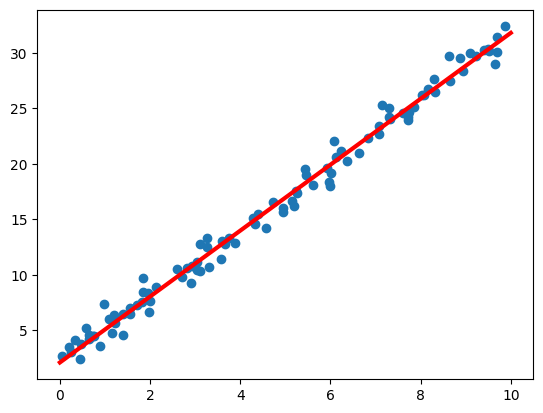

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
x_line = np.linspace(0,10,100)
y_line = model.weights*x_line + model.bias
plt.scatter(X,y)
plt.plot(x_line, y_line, color="red", label="Regression Line",linewidth=3)

In [14]:
import numpy as np

class GLM:
    def __init__(self, learning_rate=0.01, n_iters=1000, link='sigmoid'):
        self.lr = learning_rate
        self.n_iters = n_iters
        self.link = link
        self.weights = 0.0
        self.bias = 0.0

    # -------- Link Functions --------
    def _link_function(self, z):
        if self.link == 'identity':       # Linear regression
            return z
        elif self.link == 'sigmoid':      # Logistic regression
            return 1 / (1 + np.exp(-z))
        elif self.link == 'exp':          # Poisson regression
            return np.exp(z)
        else:
            raise ValueError("Unsupported link function")

    # -------- Loss Functions --------
    def _loss(self, y, y_pred):
        m = len(y)

        if self.link == 'identity':
            return np.mean((y - y_pred) ** 2)   # MSE

        elif self.link == 'sigmoid':
            eps = 1e-9
            return -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))

        elif self.link == 'exp':
            return np.mean(y_pred - y * np.log(y_pred + 1e-9))

    # -------- Fit --------
    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            z = np.dot(X, self.weights) + self.bias
            y_pred = self._link_function(z)

            # Gradients
            dz = y_pred - y
            dw = (1 / n_samples) * np.dot(X.T, dz)
            db = (1 / n_samples) * np.sum(dz)

            # Update
            self.weights -= self.lr * dw
            self.bias -= self.lr * db

    # -------- Predict --------
    def predict(self, X):
        z = np.dot(X, self.weights) + self.bias
        return self._link_function(z)

In [15]:
np.random.seed(42)

X = np.random.rand(100, 1) * 10
y = (X.squeeze() > 5).astype(int)
model = GLM(learning_rate=0.1, link='sigmoid')
model.fit(X, y)

preds = model.predict(X)
print((preds > 0.5).astype(int))

[0 1 1 1 0 0 0 1 1 1 0 1 1 0 0 0 0 1 0 0 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 1 0
 0 1 0 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 0 0 1 0 0 1 0 1 0 1 1 0 0 1
 1 1 1 0 0 0 1 1 0 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 0 0]


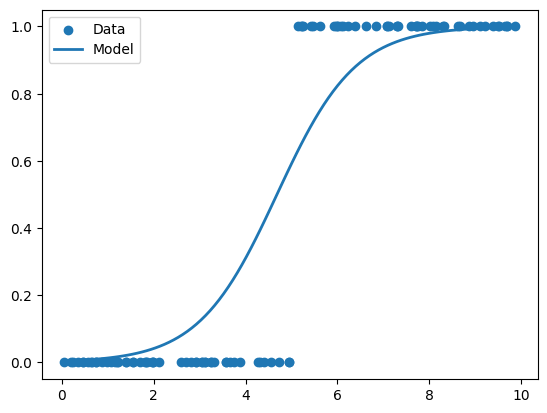

In [16]:
import matplotlib.pyplot as plt

# Scatter plot (actual data)
plt.scatter(X, y, label="Data")

# Create smooth X values
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)

# Predict using model
y_line = model._link_function(model.weights @ X_line.T  + model.bias)

# Plot line
plt.plot(X_line, y_line, label="Model", linewidth=2)

plt.legend()
plt.show()